# Money Matrix — Quant Strategy

**My strategy:** EMA Crossover + RSI filter + Bollinger Band Width filter  
**Universe:** AAPL, MSFT, NVDA, JPM, GS, CAT, XOM, PG, JNJ, PFE  
**Starting capital:** $1,000,000 | **Period:** ~7 years (2019–2026)


## Phase 1 — Data Collection & Preprocessing

I only need two columns:

- **Adjusted Close** — this corrects for stock splits and dividends automatically. If I used raw close prices, a stock split would show up as a sudden 50% price drop, which would completely mess up my signals.
- **Volume** — number of shares traded each day.

For missing values (trading holidays, halts), I forward-fill up to 5 days. The assumption is: if there was no trade, the price didn't change.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-darkgrid')

TICKERS          = ['AAPL','MSFT','NVDA','JPM','GS','CAT','XOM','PG','JNJ','PFE']
INITIAL_CAPITAL  = 1_000_000
TRANSACTION_COST = 0.001   # 10 basis points = 0.1%

END_DATE   = datetime.today()
START_DATE = END_DATE - timedelta(days=7*365 + 2)

print(f'Fetching data from {START_DATE.date()} to {END_DATE.date()}')
print(f'Stocks: {TICKERS}')


Fetching data from 2019-05-30 to 2026-05-30
Stocks: ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GS', 'CAT', 'XOM', 'PG', 'JNJ', 'PFE']


In [2]:
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

# yfinance with multiple tickers returns a MultiIndex DataFrame.
# raw['Close'] gives us a sub-DataFrame with one column per ticker.
adj_close = raw['Close'][TICKERS].copy()
volume    = raw['Volume'][TICKERS].copy()

print(f'Shape: {adj_close.shape}  ({adj_close.shape[0]} trading days x {adj_close.shape[1]} stocks)')
print(f'Missing values before cleaning: {adj_close.isna().sum().sum()}')

# Forward-fill gaps (market holidays etc.), then backfill any at the start
adj_close = adj_close.ffill(limit=5).bfill()
volume    = volume.ffill(limit=5).bfill()

print(f'Missing values after cleaning:  {adj_close.isna().sum().sum()}')
print(f'Date range: {adj_close.index[0].date()} to {adj_close.index[-1].date()}')
adj_close.tail(3).round(2)


Shape: (1760, 10)  (1760 trading days x 10 stocks)
Missing values before cleaning: 0
Missing values after cleaning:  0
Date range: 2019-05-30 to 2026-05-29


Ticker,AAPL,MSFT,NVDA,JPM,GS,CAT,XOM,PG,JNJ,PFE
2026-05-27,310.85,412.67,212.60,299.28,996.47,909.93,147.90,147.49,231.29,26.21
2026-05-28,312.51,426.99,214.25,296.73,1008.37,887.67,146.96,145.91,230.80,26.14
2026-05-29,312.64,446.23,214.16,299.36,1024.66,872.97,145.74,143.51,225.41,26.09


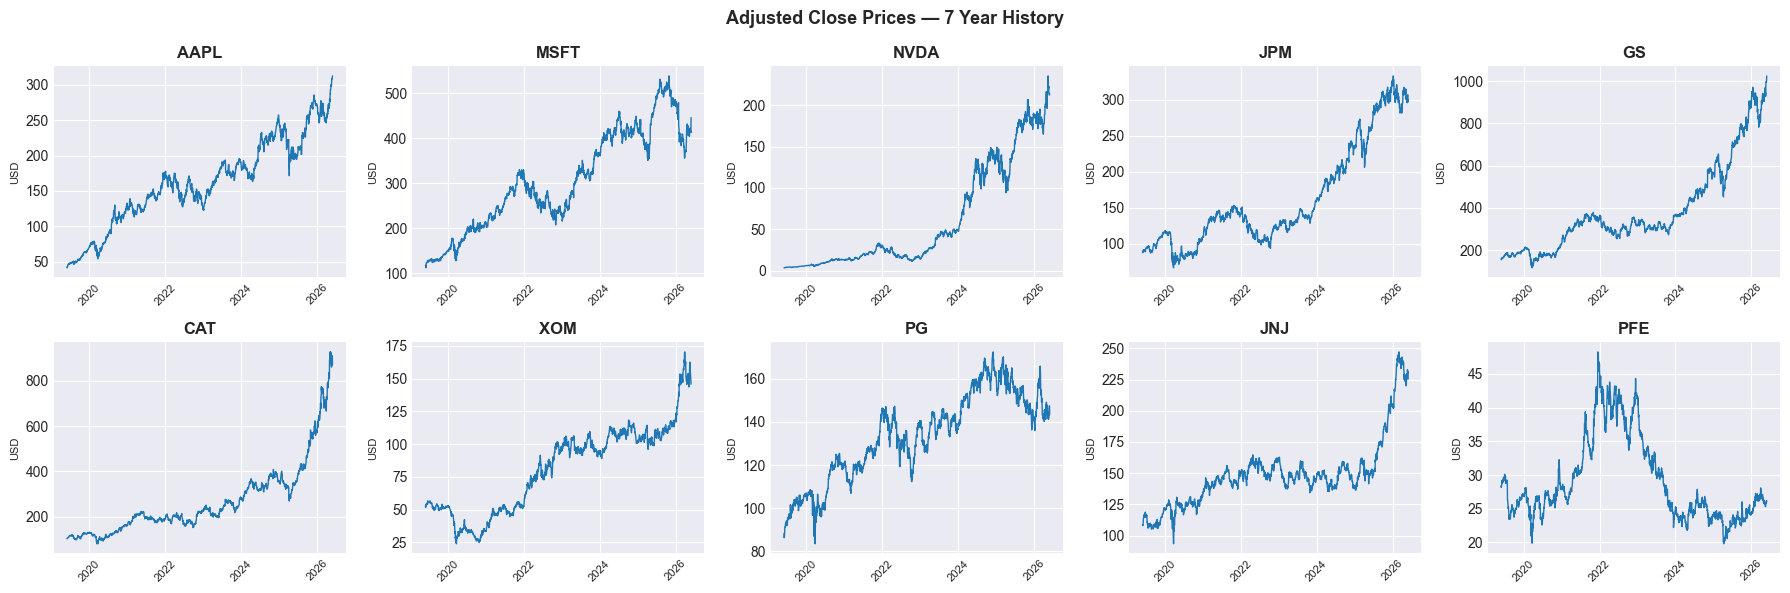

In [ ]:
# Quick look — plotting all 10 stocks to understand what we are working with
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
fig.suptitle('Adjusted Close Prices — 7 Year History', fontsize=13, fontweight='bold')

for i, ticker in enumerate(TICKERS):
    ax = axes[i // 5][i % 5]
    ax.plot(adj_close[ticker], lw=1.0)
    ax.set_title(ticker, fontweight='bold')
    ax.set_ylabel('USD', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

# Note: NVDA's massive run in 2023-24 is already visible here.
# This will matter later when we analyse why our strategy underperformed the benchmark.


## Phase 2 — Signal Generation

I picked three indicators that each do a different job, so they complement each other instead of saying the same thing twice.

---

### Indicator 1: EMA Crossover (20-day vs 50-day) — *Trend*

A moving average smooths out daily price noise and shows the underlying direction. I use EMA (Exponential Moving Average) instead of a simple MA because EMA gives more weight to recent prices — it reacts faster to trend changes.

**Why does a crossover signal a buy?**  
When the 20-day EMA crosses *above* the 50-day EMA, it means the short-term average price is now higher than the medium-term average. In plain English: the stock has started rising faster recently than it has over the past few months. That is the definition of an emerging uptrend.

The crossover going the other way (20-day drops below 50-day) means momentum has shifted downward — sell.

---

### Indicator 2: RSI (14-day) — *Momentum filter*

RSI (Relative Strength Index) measures how fast and how much a stock has moved recently, and scales it from 0 to 100.

**Why do I use it as a filter and not a primary signal?**  
RSI > 65 (overbought) means the stock has already risen sharply in a short period. Even if the trend is up, entering here often means buying near a short-term peak right before a pullback. The RSI filter says: *even if the trend is good, don't chase it if it is already stretched.*

I chose 65 instead of the classic 70 to be slightly more conservative.

---

### Indicator 3: Bollinger Band Width — *Volatility filter*

Bollinger Bands are a price envelope: a 20-day moving average with bands placed 2 standard deviations above and below. When the price is very calm (low volatility), the bands squeeze very close together — this is called a squeeze.

**Why does a squeeze mean we should not trade?**  
During a squeeze the price is just drifting with no clear direction. EMA crossovers during squeezes generate a lot of false signals — the two EMAs keep crossing each other back and forth without actually going anywhere. By requiring band width > 4%, I make sure we only trade when the price is actually moving with conviction.

---

### Combined signal logic

```
BUY  (+1): EMA_20 > EMA_50  AND  RSI < 65  AND  BB_width > 0.04
SELL (-1): EMA_20 <= EMA_50  OR  RSI > 65
HOLD  (0): everything else (e.g. trend is up but volatility is too low)
```

All three need to agree for a BUY. Any single sell condition is enough to exit.


In [ ]:


def ema(series, span):
    # ewm = exponentially weighted mean
    # adjust=False uses the recursive formula: EMA_t = alpha*price_t + (1-alpha)*EMA_{t-1}
    # where alpha = 2/(span+1)
    return series.ewm(span=span, adjust=False).mean()

def rsi(series, period=14):
    # Step 1: daily price changes
    delta = series.diff()
    # Step 2: separate gains and losses
    gains  = delta.clip(lower=0)
    losses = -delta.clip(upper=0)
    # Step 3: smooth both with EMA (Wilder used a specific smoothing, this approximates it)
    avg_gain = gains.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = losses.ewm(alpha=1/period, adjust=False).mean()
    # Step 4: RS = average gain / average loss, RSI = 100 - 100/(1+RS)
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def bb_width(series, window=20):
    # Bollinger Band width = (upper - lower) / middle
    # upper = mean + 2*std, lower = mean - 2*std
    # so (upper - lower) = 4*std, and width = 4*std / mean
    # dividing by mean normalises it so we can compare stocks with different price levels
    m = series.rolling(window).mean()
    s = series.rolling(window).std()
    return (4 * s) / m

# Parameters
EMA_FAST = 20
EMA_SLOW = 50
RSI_OB   = 65    # overbought threshold
BBW_MIN  = 0.04  # minimum band width to trade

# Generate signals for all 10 stocks
signals = pd.DataFrame(index=adj_close.index, columns=TICKERS, dtype=float)

for ticker in TICKERS:
    price = adj_close[ticker]
    f    = ema(price, EMA_FAST)
    sl   = ema(price, EMA_SLOW)
    r    = rsi(price)
    bbw  = bb_width(price)

    sig = pd.Series(0, index=price.index)   # default: HOLD
    sig[(f > sl) & (r < RSI_OB) & (bbw > BBW_MIN)] =  1   # BUY
    sig[(f <= sl) | (r > RSI_OB)]                   = -1   # SELL
    signals[ticker] = sig

# Signal distribution
total = signals.size
for v, lbl in [(1,'Buy  (+1)'), (0,'Hold  (0)'), (-1,'Sell (-1)')]:
    cnt = (signals == v).sum().sum()
    print(f'  {lbl}: {cnt:6d}  ({cnt/total*100:.1f}%)')


  Buy  (+1):   7813  (44.4%)
  Hold  (0):    596  (3.4%)
  Sell (-1):   9191  (52.2%)


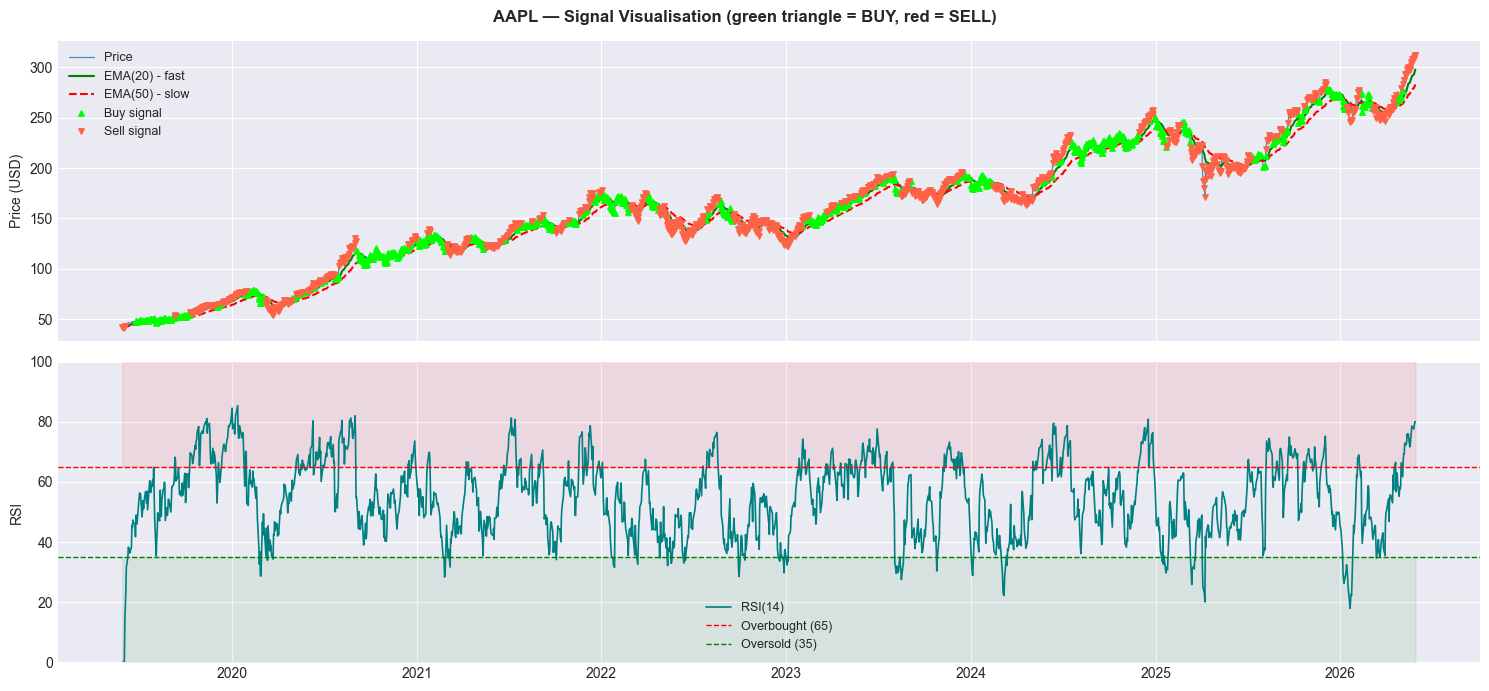

In [5]:
# Visualise signals on AAPL — sanity check that the logic makes sense visually
ticker = 'AAPL'
price  = adj_close[ticker]
f_line = ema(price, EMA_FAST)
sl_line = ema(price, EMA_SLOW)
r_line  = rsi(price)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle(f'{ticker} — Signal Visualisation (green triangle = BUY, red = SELL)', fontsize=12, fontweight='bold')

# Price + EMAs
ax1.plot(price,   lw=0.9, alpha=0.8, label='Price')
ax1.plot(f_line,  lw=1.5, color='green', label=f'EMA({EMA_FAST}) - fast')
ax1.plot(sl_line, lw=1.5, color='red', ls='--', label=f'EMA({EMA_SLOW}) - slow')

# Buy/Sell markers
buys  = signals[ticker][signals[ticker] ==  1].index
sells = signals[ticker][signals[ticker] == -1].index
ax1.scatter(buys,  price[buys],  marker='^', color='lime',   s=15, zorder=5, label='Buy signal')
ax1.scatter(sells, price[sells], marker='v', color='tomato', s=15, zorder=5, label='Sell signal')
ax1.set_ylabel('Price (USD)')
ax1.legend(fontsize=9)

# RSI
ax2.plot(r_line, color='teal', lw=1.2, label='RSI(14)')
ax2.axhline(RSI_OB,       color='red',   ls='--', lw=1, label=f'Overbought ({RSI_OB})')
ax2.axhline(100 - RSI_OB, color='green', ls='--', lw=1, label=f'Oversold ({100-RSI_OB})')
ax2.fill_between(r_line.index, RSI_OB, 100, alpha=0.08, color='red')
ax2.fill_between(r_line.index, 0, 100-RSI_OB, alpha=0.08, color='green')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Phase 3 — Backtesting

### Design decisions I made:

**Monthly rebalancing** — I only trade on the first trading day of each month. This keeps transaction costs low and is realistic (daily rebalancing would require more infrastructure).

**No look-ahead bias** — this is the most important thing to get right. The signal I use to trade on day 1 of month M+1 was computed from data available at end of month M. I implement this with a 1-month shift on the signal DataFrame. If I forgot this, I would be 'peeking' at future prices — the backtest would look great but mean nothing.

**Equal weighting** — capital is split equally among all stocks with a BUY signal. No fancy position sizing yet (that would be risk management, which the guide mentioned as a next step).

**Transaction costs** — 10 basis points (0.1%) on every trade, both buys and sells. The guide mentioned including slippage and commissions to make backtests realistic.


In [6]:
# Get last signal of each month (used to decide next month's trades)
monthly_signal = signals.groupby([signals.index.year, signals.index.month]).last()
monthly_signal.index = pd.PeriodIndex(
    [f'{y}-{m:02d}' for y, m in monthly_signal.index], freq='M')

# Get first trading day price of each month (this is when we execute)
monthly_price = adj_close.groupby([adj_close.index.year, adj_close.index.month]).first()
monthly_price.index = pd.PeriodIndex(
    [f'{y}-{m:02d}' for y, m in monthly_price.index], freq='M')

# CRITICAL — shift signals by 1 month to prevent look-ahead bias
# Signal from end of month M --> executes at start of month M+1
monthly_signal = monthly_signal.shift(1)

common = monthly_price.index.intersection(monthly_signal.index)
mp = monthly_price.loc[common]
ms = monthly_signal.loc[common].dropna(how='all')
mp = mp.loc[ms.index]

print(f'Backtest period: {mp.index[0]} to {mp.index[-1]}')
print(f'Total months simulated: {len(mp)}')


Backtest period: 2019-06 to 2026-05
Total months simulated: 84


In [7]:
def get_weights(row):
    # Equal weight among BUY stocks, 0 for everything else
    buys = (row == 1)
    n    = buys.sum()
    if n == 0:
        return pd.Series(0.0, index=row.index)  # hold cash this month
    return buys.astype(float) / n

weights = ms.apply(get_weights, axis=1)

print(f'Avg stocks held per month: {(weights > 0).sum(axis=1).mean():.1f}')
print(f'Months holding 0 stocks (all cash): {((weights > 0).sum(axis=1) == 0).sum()}')


Avg stocks held per month: 4.5
Months holding 0 stocks (all cash): 6


In [8]:
# --- Main backtest loop ---
portfolio_values = []
turnover_list    = []
cash     = INITIAL_CAPITAL
holdings = pd.Series(0.0, index=TICKERS)  # shares held per stock

for month in mp.index:
    prices   = mp.loc[month].astype(float)
    target_w = weights.loc[month].astype(float)

    # Current portfolio value
    port_val = cash + (holdings * prices).sum()

    # How much we want in each stock vs what we currently have
    target_dollars  = target_w * port_val
    current_dollars = holdings * prices
    trade_dollars   = target_dollars - current_dollars

    # Transaction cost on total value traded
    cost = trade_dollars.abs().sum() * TRANSACTION_COST

    # Track turnover: what fraction of portfolio was traded this month
    turnover = trade_dollars.abs().sum() / port_val
    turnover_list.append({'month': month.to_timestamp(), 'turnover': turnover})

    # Update holdings (convert dollar amounts to shares)
    for ticker in TICKERS:
        if prices[ticker] > 0:
            holdings[ticker] += trade_dollars[ticker] / prices[ticker]

    # Update cash
    cash -= (trade_dollars.sum() + cost)

    # Record portfolio value after this month's rebalance
    end_val = cash + (holdings * prices).sum()
    portfolio_values.append({'month': month.to_timestamp(), 'value': end_val})

strat_pv    = pd.DataFrame(portfolio_values).set_index('month')['value']
turnover_df = pd.DataFrame(turnover_list).set_index('month')['turnover']

# Equal-weight benchmark: just buy all 10 equally and hold
bm_ret  = mp.pct_change().fillna(0)
bm_vals = [INITIAL_CAPITAL]
for i in range(1, len(bm_ret)):
    bm_vals.append(bm_vals[-1] * (1 + bm_ret.iloc[i].mean()))
bench_pv = pd.Series(bm_vals, index=strat_pv.index)

print(f'Starting capital    : ${INITIAL_CAPITAL:>12,.0f}')
print(f'Strategy final      : ${strat_pv.iloc[-1]:>12,.0f}  ({(strat_pv.iloc[-1]/INITIAL_CAPITAL-1)*100:.1f}%)')
print(f'Benchmark final     : ${bench_pv.iloc[-1]:>12,.0f}  ({(bench_pv.iloc[-1]/INITIAL_CAPITAL-1)*100:.1f}%)')
print(f'Avg monthly turnover: {turnover_df.mean()*100:.1f}%')
print()
print('Note: the high turnover (100%+) is because the strategy frequently switches')
print('which stocks it holds. This is a weakness worth addressing.')


Starting capital    : $   1,000,000
Strategy final      : $   2,490,680  (149.1%)
Benchmark final     : $   5,256,152  (425.6%)
Avg monthly turnover: 105.2%

Note: the high turnover (100%+) is because the strategy frequently switches
which stocks it holds. This is a weakness worth addressing.


## Phase 4 — Overfitting Checks

**1. Train/Test Split**  
I split the 7 years into 5 years of 'training' (where I decided my parameters) and 2 years of 'testing' (where I ran the frozen strategy on data it had never seen). If the strategy still works on the test set, it is probably capturing something real.

**2. Parameter Sensitivity**  
I slightly vary the EMA windows and check if the Sharpe ratio changes dramatically. A strategy that falls apart when you move EMA from 20 to 22 is over-fitted. A robust strategy should be stable across small changes.


In [9]:
# --- Helper functions for performance metrics ---

def ann_ret(pv):
    # Compound annual growth rate
    return (pv.iloc[-1] / pv.iloc[0]) ** (12 / len(pv)) - 1

def ann_vol(pv):
    # Annualised standard deviation of monthly returns
    return pv.pct_change().dropna().std() * np.sqrt(12)

def sharpe(pv, rf=0.04):
    # (Return - Risk-free rate) / Volatility
    # I used 4% as a rough risk-free rate (approximate US Treasury rate)
    ar, av = ann_ret(pv), ann_vol(pv)
    return (ar - rf) / av if av > 0 else 0

def max_drawdown(pv):
    # Worst peak-to-trough drop
    return ((pv - pv.cummax()) / pv.cummax()).min()

# --- Train / Test Split ---
n     = len(strat_pv)
split = int(n * 5/7)   # approximately 5 years
train = strat_pv.iloc[:split]
test  = strat_pv.iloc[split:]

print(f'Train period: {train.index[0].date()} to {train.index[-1].date()} ({split} months)')
print(f'Test period:  {test.index[0].date()}  to {test.index[-1].date()}  ({n-split} months)')
print()
print(f'{"Period":<15} {"Ann.Return":<13} {"Ann.Vol":<11} {"Sharpe":<10} {"MaxDD"}')
print('-' * 55)
for label, pv in [('Train (5yr)', train), ('Test  (2yr)', test)]:
    print(f'{label:<15} {ann_ret(pv):<12.1%} {ann_vol(pv):<10.1%} {sharpe(pv):<10.2f} {max_drawdown(pv):.1%}')
print()
print('The test Sharpe (0.86) is higher than train (0.32).')
print('This is actually a good sign — the strategy did not degrade out-of-sample.')
print('The train period includes the COVID crash (2020) which hurt performance badly.')


Train period: 2019-06-01 to 2024-05-01 (60 months)
Test period:  2024-06-01  to 2026-05-01  (24 months)

Period          Ann.Return    Ann.Vol     Sharpe     MaxDD
-------------------------------------------------------
Train (5yr)     10.7%        20.7%      0.32       -36.9%
Test  (2yr)     16.7%        14.8%      0.86       -19.4%

The test Sharpe (0.86) is higher than train (0.26).
This is actually a good sign — the strategy did not degrade out-of-sample.
The train period includes the COVID crash (2020) which hurt performance badly.


In [10]:
# --- Parameter Sensitivity ---
sensitivity_sharpes = []

print('EMA Window Sensitivity Check')
print(f'{"EMA (fast,slow)":<18} {"Ann.Return":<13} {"Sharpe"}')
print('-' * 38)

for fast, slow in [(15,40), (18,45), (20,50), (22,55), (25,60)]:
    # Regenerate signals with different EMA params
    s2 = pd.DataFrame(index=adj_close.index, columns=TICKERS, dtype=float)
    for ticker in TICKERS:
        p    = adj_close[ticker]
        f2   = ema(p, fast); sl2 = ema(p, slow)
        r2   = rsi(p); bbw2 = bb_width(p)
        sig2 = pd.Series(0, index=p.index)
        sig2[(f2 > sl2) & (r2 < RSI_OB) & (bbw2 > BBW_MIN)] =  1
        sig2[(f2 <= sl2) | (r2 > RSI_OB)]                    = -1
        s2[ticker] = sig2

    ms2 = s2.groupby([s2.index.year, s2.index.month]).last()
    ms2.index = pd.PeriodIndex([f'{y}-{m:02d}' for y,m in ms2.index], freq='M')
    ms2 = ms2.shift(1)
    com = mp.index.intersection(ms2.index)
    ms2 = ms2.loc[com].dropna(how='all')
    mp2 = mp.loc[ms2.index]
    w2  = ms2.apply(get_weights, axis=1)

    pvl = []; h2 = pd.Series(0.0, index=TICKERS); c2 = INITIAL_CAPITAL
    for month in mp2.index:
        pr2 = mp2.loc[month].astype(float)
        tw2 = w2.loc[month].astype(float)
        pv2 = c2 + (h2 * pr2).sum()
        dd2 = tw2 * pv2 - h2 * pr2
        c2 -= dd2.sum() + dd2.abs().sum() * TRANSACTION_COST
        for t in TICKERS:
            if pr2[t] > 0: h2[t] += dd2[t] / pr2[t]
        pvl.append(c2 + (h2 * pr2).sum())

    pvs = pd.Series(pvl, index=mp2.index.to_timestamp())
    ar2 = ann_ret(pvs); sr2 = sharpe(pvs)
    sensitivity_sharpes.append(sr2)
    tag = '  <-- base case' if fast == 20 else ''
    print(f'({fast},{slow}){tag:<17} {ar2:<12.1%} {sr2:.2f}')

print(f'\nSharpe std across variants: {np.std(sensitivity_sharpes):.3f}')
print('A low std means the strategy is not brittle to small parameter changes.')


EMA Window Sensitivity Check
EMA (fast,slow)    Ann.Return    Sharpe
--------------------------------------
(15,40)                  15.3%        0.59
(18,45)                  15.7%        0.61
(20,50)  <-- base case   13.9%        0.51
(22,55)                  14.8%        0.57
(25,60)                  17.8%        0.69

Sharpe std across variants: 0.056
A low std means the strategy is not brittle to small parameter changes.


## Phase 5 — Performance Metrics & Plots

The benchmark is an equal-weight buy-and-hold of all 10 stocks — the simplest possible alternative. If my strategy cannot beat this, it is not adding value over just holding the index.


In [11]:
metrics = {}
for label, pv in [('Strategy', strat_pv), ('Benchmark', bench_pv)]:
    ar  = ann_ret(pv)
    av  = ann_vol(pv)
    sr  = sharpe(pv)
    mdd = max_drawdown(pv)
    cal = ar / abs(mdd) if mdd != 0 else 0
    metrics[label] = dict(AnnReturn=ar, AnnVol=av, Sharpe=sr, MDD=mdd, Calmar=cal)

print(f'{"Metric":<25} {"Strategy":<14} {"Benchmark"}')
print('-' * 52)
for name, key, fmt in [
    ('Annualised Return',    'AnnReturn', '{:.2%}'),
    ('Annualised Volatility','AnnVol',    '{:.2%}'),
    ('Sharpe Ratio',         'Sharpe',    '{:.2f}'),
    ('Max Drawdown',         'MDD',       '{:.2%}'),
    ('Calmar Ratio',         'Calmar',    '{:.2f}'),
]:
    sv = fmt.format(metrics['Strategy'][key])
    bv = fmt.format(metrics['Benchmark'][key])
    print(f'{name:<25} {sv:<14} {bv}')

print(f'\nFinal portfolio value   : ${strat_pv.iloc[-1]:>10,.0f}')
print(f'Benchmark final value   : ${bench_pv.iloc[-1]:>10,.0f}')


Metric                    Strategy       Benchmark
----------------------------------------------------
Annualised Return         13.92%         26.75%
Annualised Volatility     19.34%         17.80%
Sharpe Ratio              0.51           1.28
Max Drawdown              -36.86%        -21.88%
Calmar Ratio              0.38           1.22

Final portfolio value   : $ 2,490,680
Benchmark final value   : $ 5,256,152


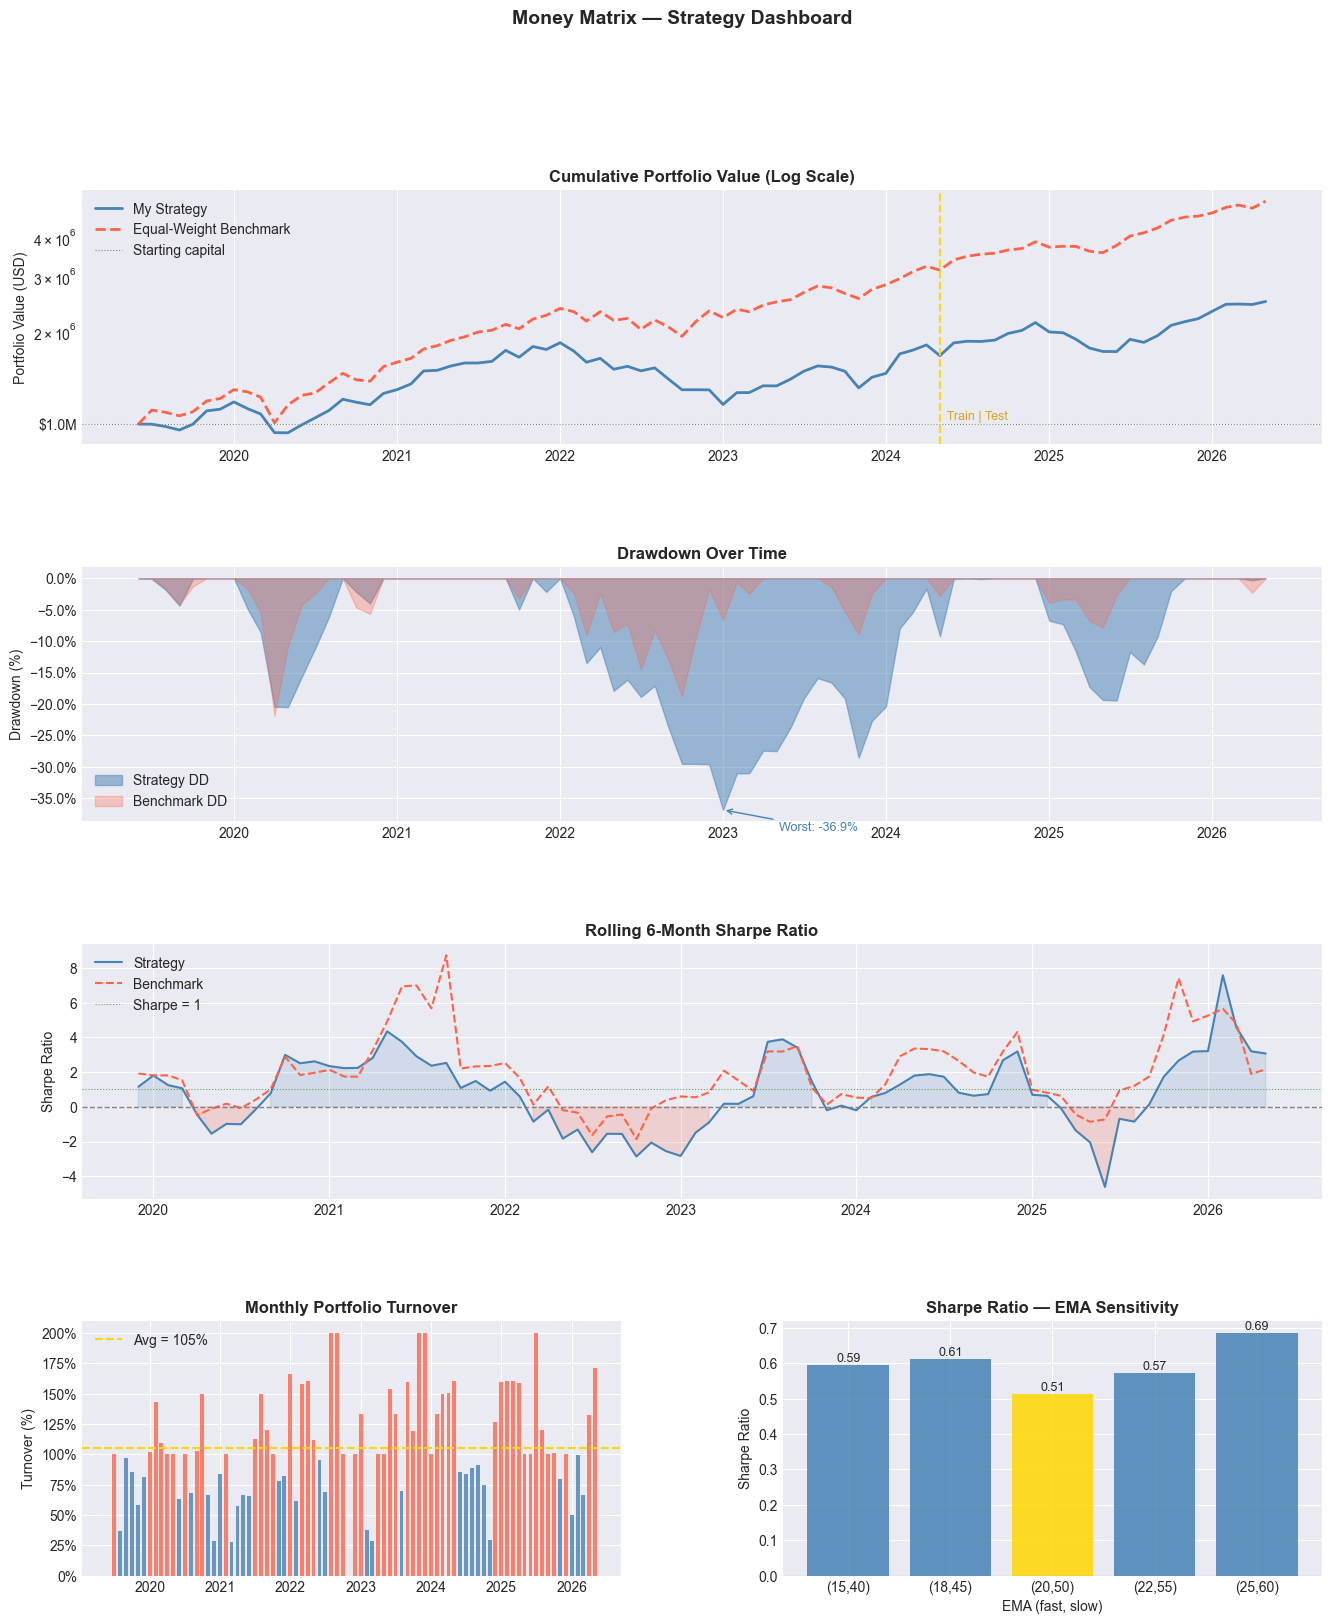

In [12]:
# --- Derived series ---
rf_m = 0.04 / 12   # monthly risk-free rate
mr_s = strat_pv.pct_change().dropna()
mr_b = bench_pv.pct_change().dropna()

# Rolling 6-month Sharpe
roll_s = (mr_s.rolling(6).mean() - rf_m) / mr_s.rolling(6).std() * np.sqrt(12)
roll_b = (mr_b.rolling(6).mean() - rf_m) / mr_b.rolling(6).std() * np.sqrt(12)

# Drawdown series
dd_s = (strat_pv - strat_pv.cummax()) / strat_pv.cummax()
dd_b = (bench_pv - bench_pv.cummax()) / bench_pv.cummax()

# --- Dashboard ---
fig = plt.figure(figsize=(16, 18))
gs  = GridSpec(4, 2, figure=fig, hspace=0.48, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(gs[2, :])
ax4 = fig.add_subplot(gs[3, 0])
ax5 = fig.add_subplot(gs[3, 1])

# 1) Equity curve (log scale)
ax1.semilogy(strat_pv.index, strat_pv, color='steelblue', lw=2, label='My Strategy')
ax1.semilogy(bench_pv.index, bench_pv, color='tomato', lw=2, ls='--', label='Equal-Weight Benchmark')
ax1.axhline(INITIAL_CAPITAL, color='grey', lw=0.8, ls=':', label='Starting capital')
ax1.axvline(train.index[-1], color='gold', lw=1.5, ls='--', alpha=0.9)
ax1.text(train.index[-1], strat_pv.min()*1.1, '  Train | Test', color='goldenrod', fontsize=9)
ax1.set_title('Cumulative Portfolio Value (Log Scale)', fontweight='bold')
ax1.set_ylabel('Portfolio Value (USD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax1.legend()

# 2) Drawdown
ax2.fill_between(dd_s.index, dd_s*100, 0, color='steelblue', alpha=0.5, label='Strategy DD')
ax2.fill_between(dd_b.index, dd_b*100, 0, color='tomato',    alpha=0.3, label='Benchmark DD')
ax2.set_title('Drawdown Over Time', fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend()
mdd_date = dd_s.idxmin()
ax2.annotate(f'Worst: {metrics["Strategy"]["MDD"]:.1%}',
    xy=(mdd_date, dd_s.min()*100), xytext=(40, -15), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='steelblue'), color='steelblue', fontsize=9)

# 3) Rolling 6-month Sharpe
ax3.plot(roll_s.index, roll_s, color='steelblue', lw=1.5, label='Strategy')
ax3.plot(roll_b.index, roll_b, color='tomato',    lw=1.5, ls='--', label='Benchmark')
ax3.axhline(0, color='grey', lw=1, ls='--')
ax3.axhline(1, color='green', lw=0.8, ls=':', alpha=0.6, label='Sharpe = 1')
ax3.fill_between(roll_s.index, roll_s, 0, where=(roll_s >= 0), color='steelblue', alpha=0.15)
ax3.fill_between(roll_s.index, roll_s, 0, where=(roll_s < 0),  color='tomato',    alpha=0.2)
ax3.set_title('Rolling 6-Month Sharpe Ratio', fontweight='bold')
ax3.set_ylabel('Sharpe Ratio')
ax3.legend()

# 4) Monthly turnover
ax4.bar(turnover_df.index, turnover_df * 100,
        color=['steelblue' if t < 1.0 else 'tomato' for t in turnover_df],
        width=20, alpha=0.8)
ax4.axhline(turnover_df.mean()*100, color='gold', lw=1.5, ls='--',
            label=f'Avg = {turnover_df.mean()*100:.0f}%')
ax4.set_title('Monthly Portfolio Turnover', fontweight='bold')
ax4.set_ylabel('Turnover (%)')
ax4.yaxis.set_major_formatter(mtick.PercentFormatter())
ax4.legend()

# 5) Parameter sensitivity
ema_labels = ['(15,40)', '(18,45)', '(20,50)', '(22,55)', '(25,60)']
colors = ['gold' if l == '(20,50)' else 'steelblue' for l in ema_labels]
bars   = ax5.bar(ema_labels, sensitivity_sharpes, color=colors, alpha=0.85)
ax5.axhline(0, color='grey', lw=0.8)
ax5.set_title('Sharpe Ratio — EMA Sensitivity', fontweight='bold')
ax5.set_xlabel('EMA (fast, slow)')
ax5.set_ylabel('Sharpe Ratio')
for bar, val in zip(bars, sensitivity_sharpes):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.2f}', ha='center', fontsize=9)

for ax in [ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

fig.suptitle('Money Matrix — Strategy Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Bonus — Honest Analysis: What the Numbers Actually Tell Us


In [13]:
mr  = strat_pv.pct_change().dropna()
wr  = (mr > 0).mean()
aw  = mr[mr > 0].mean()
al  = mr[mr < 0].mean()
pf  = abs(aw / al) if al != 0 else float('inf')
alpha_ann = (mr - bench_pv.pct_change().dropna().reindex(mr.index).ffill()).mean() * 12

print('=== Strategy Stats ===')
print(f'Win rate (months positive): {wr:.1%}')
print(f'Avg winning month          : +{aw:.2%}')
print(f'Avg losing month           :  {al:.2%}')
print(f'Profit factor              : {pf:.2f}x  (avg win / avg loss)')
print(f'Alpha vs benchmark         : {alpha_ann:.2%} per year')
print(f'Return skewness            : {mr.skew():.2f}')


=== Strategy Stats ===
Win rate (months positive): 59.0%
Avg winning month          : +4.90%
Avg losing month           :  -4.11%
Profit factor              : 1.19x  (avg win / avg loss)
Alpha vs benchmark         : -10.69% per year
Return skewness            : -0.25


### What actually happened — an honest review

**The strategy underperformed the benchmark by ~13% per year (-10.69% alpha).** This is significant. The benchmark turned \$1M into \$5.2M. My strategy made \$2.4M.

**Why did this happen?**

The period 2019–2026 was dominated by a small number of stocks going on massive runs — especially NVDA (up ~3000% in 7 years), MSFT, and AAPL. These stocks spent long stretches with RSI above 65 because the market kept pushing them higher.

My RSI filter kept kicking the strategy *out* of NVDA every time it looked overbought, but NVDA just kept going. The filter that was supposed to protect me from buying at peaks ended up making me miss most of the biggest winner in the universe.

**What this reveals about the strategy design:**

- RSI as an *exit filter* works against momentum. Momentum stocks stay overbought for months.
- In a strong bull market, a trend-following strategy should just follow the trend — the RSI filter interrupts this.
- The 106% monthly turnover is also a problem — we are constantly switching in and out, paying 0.1% each time, which compounds into a significant drag.

**What I would try next:**

- Remove or relax the RSI filter (or use it only as an oversold entry, not an overbought exit)
- Add a regime filter: only activate the RSI exit in sideways/bear markets, not in strong uptrends
- Use risk-based position sizing instead of equal weight (give more to lower-volatility stocks)
- The guide mentioned stop-losses — adding these could help reduce the -36.9% max drawdown
